# 14 — Cross-Source Integration & Pre-Load Compatibility Assessment

**Authors:** Gustavo Fuentes (`Audileleach`, Lead Analyst) & Jose Pech (`joseeangel0`, Support & DW Lead)  
**Project:** Mexico City Urban Intelligence (Phase 1 — Cross-Source Evidence)  
**Scope & Contract Reference:** `docs/team/TEAM_PLAN.md` §3.1, §3.5, and §4.6; `data/raw/manifest.json`  

## Purpose and Analytical Scope

While individual profiling notebooks (`10_geographic_assessment.ipynb`, `11_profile_census.ipynb`, `12_profile_denue.ipynb`, and `13_profile_crime.ipynb`) evaluate isolated datasets, this notebook provides the **cross-source integration evidence** required by Phase 1 before ETL ingestion. Specifically, it establishes:

1. **Geographic Key & Polygon Compatibility:** Validates zero-padded 13-character `CVEGEO` keys between Census 2020 urban aggregates and cartographic polygons (`09a.shp`), quantifying the two orphan census keys excluded from the spatial frame.
2. **DENUE Geographic Code vs. Spatial Join Concordance:** Compares reported administrative identifiers (`cve_ent` + `cve_mun` + `cve_loc` + `ageb`) against point-in-polygon spatial assignment using the shared `assign_ageb` helper in `EPSG:6372`, quantifying agreement rates and boundary mismatches at the establishment grain.
3. **Cross-Source Temporal Coverage Mismatch:** Distinguishes the decennial stock measurement of Census 2020 (March 2020), the directory snapshot nature and registration waves (`fecha_alta`) of DENUE 05/2026, and the 7-month procedural filing window (`fecha_inicio`, Jan–Jul 2024) of FGJ crime files. Emphasizes the unavailability of Aug–Dec 2024 crime data and July right-censoring.
4. **Source-to-Urban-AGEB Summary Funnel Table:** Reconciles raw inputs to retained warehouse entities (2,431 polygons, 9,138,524 residents, 461,231 establishments, and 112,285 crime incidents), establishing the analytical boundaries for Phase 2 ETL and Phase 3 analytics.

In [1]:
from pathlib import Path
import sys

# Ensure project root is available on sys.path
ROOT = next((parent for parent in (Path.cwd(), *Path.cwd().parents) if (parent / "src").is_dir()), Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from IPython.display import Image, display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.analysis.integration import (
    build_source_integration_summary_table,
    census_polygon_compatibility,
    crime_temporal_and_grain_check,
    denue_code_compatibility,
    plot_cross_source_temporal_coverage,
)
from src.config import CRIME_YEAR, DATA_RAW, OUTPUT_FIGURES
from src.transform.census import read_census, select_ageb_rows
from src.transform.denue import read_denue
from src.transform.spatial import assign_ageb, load_ageb, points_from_latlon

print(f"Project root resolved: {ROOT}")
print(f"Raw data directory: {DATA_RAW}")

Project root resolved: /Users/joseangel/Developer/E2 Datawarehouse Design/merida-urban-intelligence
Raw data directory: /Users/joseangel/Developer/E2 Datawarehouse Design/merida-urban-intelligence/data/raw


## 1. Census-to-Polygon CVEGEO Compatibility

In Mexico's national statistical system, the geostatistical identifier `CVEGEO` encodes hierarchical administration:  
$$\text{CVEGEO} = \underbrace{\text{ENTIDAD}}_{2\text{ digits}} + \underbrace{\text{MUN}}_{3\text{ digits}} + \underbrace{\text{LOC}}_{4\text{ digits}} + \underbrace{\text{AGEB}}_{4\text{ chars}} = 13\text{ characters}$$

In the raw Censo de Población y Vivienda 2020 (`conjunto_de_datos_ageb_urbana_09_cpv2020.csv`), rows mix multiple nested aggregates (state total, alcaldía totals, locality totals, AGEB totals, and block totals). To prevent double-counting, we isolate strictly the **urban AGEB total rows** (`MZA == '000'` and `AGEB != '0000'`).

We test this key set against the official 2020 cartographic layer (`09a.shp` / `ageb.parquet`).

In [2]:
# Execute census compatibility evaluation
census_comp = census_polygon_compatibility()

print("=== Census 2020 vs. Urban AGEB Polygons Compatibility ===")
print(f"Total urban AGEB records in Census 2020:  {census_comp['total_census_agebs']:,}")
print(f"Matched AGEBs with cartographic polygons:  {census_comp['matched_agebs']:,}")
print(f"Orphan Census AGEBs lacking polygons:     {census_comp['orphan_count']:,}")
print(f"Total population in matched urban AGEBs:  {census_comp['matched_population']:,}")
print(f"Total population in orphan AGEBs:         {census_comp['orphan_population']:,}")

display(census_comp["orphan_summary"])

# Contract assertions
assert census_comp["matched_agebs"] == 2_431, f"Expected 2,431 matched AGEBs, got {census_comp['matched_agebs']}"
assert census_comp["matched_population"] == 9_138_524, f"Expected 9,138,524 matched population, got {census_comp['matched_population']}"
assert census_comp["orphan_keys"] == ["0901101101107", "0901201351227"], f"Unexpected orphan keys: {census_comp['orphan_keys']}"
assert census_comp["orphan_population"] == 7_108, f"Expected 7,108 orphan residents, got {census_comp['orphan_population']}"
print("\n[OK] Census-polygon compatibility successfully reproduces TEAM_PLAN §3.5 reference values.")

=== Census 2020 vs. Urban AGEB Polygons Compatibility ===
Total urban AGEB records in Census 2020:  2,433
Matched AGEBs with cartographic polygons:  2,431
Orphan Census AGEBs lacking polygons:     2
Total population in matched urban AGEBs:  9,138,524
Total population in orphan AGEBs:         7,108


,cvegeo,mun_name,cve_mun,pop_total
0,0901101101107,Tláhuac,011,3050
1,0901201351227,Tlalpan,012,4058



[OK] Census-polygon compatibility successfully reproduces TEAM_PLAN §3.5 reference values.


### Methodological Note on Census Exclusions

Two urban AGEBs present in the Census 2020 tables have no corresponding polygon geometry in the INEGI Marco Geoestadístico 2020 (`09a.shp`):
- **`0901101101107`** (Alcaldía Tláhuac, `cve_mun='011'`): 3,050 residents
- **`0901201351227`** (Alcaldía Tlalpan, `cve_mun='012'`): 4,058 residents
- **Total excluded population:** 7,108 residents (~0.078% of the 9,145,632 urban census residents).

**Why these exclusions matter:**  
1. **Spatial Join Viability:** Because these two units lack boundary polygons, point observations (DENUE establishments and FGJ crime incidents) cannot be spatially linked to them using point-in-polygon predicates (`within`).
2. **Spatial Weights & Autocorrelation:** PySAL contiguity matrices (Queen / KNN) require valid polygon topologies. Non-spatial tabular units would disrupt neighbourhood graphs and spatial lag computations.
3. **Coverage Impact:** Retaining 2,431 AGEBs preserves **99.92%** of urban census residents and **99.22%** of the entire state population (9,209,944). This trade-off preserves topological completeness without distorting demographic rates.

## 2. DENUE Reported Geographic Codes vs. Point-in-Polygon Spatial Assignment

The DENUE economic directory publishes nominal administrative codes for each establishment (`cve_ent`, `cve_mun`, `cve_loc`, and `ageb`), which can be concatenated into `cvegeo_reported`. In parallel, each establishment includes GPS coordinates (`latitud`, `longitud`).

To prevent boundary artefacts and guarantee physical spatial containment, our pipeline applies a geometric point-in-polygon join using `assign_ageb` with predicate `within` against the EPSG:6372 AGEB polygons. Here we compute the precise concordance between reported codes and spatially assigned codes.

In [3]:
# Execute DENUE code compatibility evaluation
denue_comp = denue_code_compatibility()

print("=== DENUE Reported Code vs. Spatial Join Concordance ===")
print(f"Total raw economic establishments:       {denue_comp['raw_count']:,}")
print(f"Establishments with valid coordinates:    {denue_comp['valid_coords_count']:,}")
print(f"Retained inside urban AGEB polygons:      {denue_comp['retained_count']:,}")
print(f"Dropped outside urban AGEB polygons:      {denue_comp['outside_count']:,}")
print(f"Reported code matched assigned polygon:   {denue_comp['matched_cvegeo']:,}")
print(f"Reported code mismatched assigned polygon:{denue_comp['mismatched_cvegeo']:,}")
print(f"Concordance rate among retained points:   {denue_comp['agreement_rate']:.4%}")

# Breakdown table
denue_breakdown = pd.DataFrame([
    {"Classification": "Exact Agreement (Reported == Spatial Join)", "Count": denue_comp["matched_cvegeo"], "Share of Retained (%)": round(denue_comp["matched_cvegeo"] / denue_comp["retained_count"] * 100, 2)},
    {"Classification": "Boundary Mismatch (Reported != Spatial Join)", "Count": denue_comp["mismatched_cvegeo"], "Share of Retained (%)": round(denue_comp["mismatched_cvegeo"] / denue_comp["retained_count"] * 100, 2)},
    {"Classification": "Retained Total (Inside Urban AGEBs)", "Count": denue_comp["retained_count"], "Share of Retained (%)": 100.0},
    {"Classification": "Excluded Outside Urban AGEBs", "Count": denue_comp["outside_count"], "Share of Retained (%)": np.nan},
    {"Classification": "Total Raw Establishments", "Count": denue_comp["raw_count"], "Share of Retained (%)": np.nan},
])
display(denue_breakdown)

# Contract assertions
assert denue_comp["raw_count"] == 462_732
assert denue_comp["retained_count"] == 461_231
assert denue_comp["matched_cvegeo"] == 460_503
assert denue_comp["mismatched_cvegeo"] == 728
assert denue_comp["outside_count"] == 1_501
assert abs(denue_comp["agreement_rate"] - 0.998422) < 1e-5
print("\n[OK] DENUE code compatibility matches contract reference values (461,231 retained; 99.84% agreement).")

Dropped 3 invalid/out-of-study-area coordinates from 462732 rows.


kept 461231 / 462729 (99.7%)
=== DENUE Reported Code vs. Spatial Join Concordance ===
Total raw economic establishments:       462,732
Establishments with valid coordinates:    462,729
Retained inside urban AGEB polygons:      461,231
Dropped outside urban AGEB polygons:      1,501
Reported code matched assigned polygon:   460,503
Reported code mismatched assigned polygon:728
Concordance rate among retained points:   99.8422%


,Classification,Count,Share of Retained (%)
0,Exact Agreement (Reported == Spatial Join),460503,99.84
1,Boundary Mismatch (Reported != Spatial Join),728,0.16
2,Retained Total (Inside Urban AGEBs),461231,100.00
3,Excluded Outside Urban AGEBs,1501,NaN
4,Total Raw Establishments,462732,NaN



[OK] DENUE code compatibility matches contract reference values (461,231 retained; 99.84% agreement).


### Methodological Interpretation of DENUE Concordance

1. **Near-Universal Agreement (99.84%):** Out of 461,231 geolocated establishments retained within urban polygons, **460,503** have an identical `CVEGEO` between their administratively reported identifier and their spatial point-in-polygon assignment.
2. **Boundary-Straddling Establishments (728 establishments, 0.16%):** The 728 mismatches arise when an establishment's street address was assigned to a given administrative parcel during manual survey entry, but the geocoded GPS coordinate falls immediately across the street or parcel border into an adjacent AGEB.
3. **Topological Rule Priority:** Relying on `within` spatial intersection rather than self-reported text codes guarantees that all spatial aggregations (e.g. business density $\text{businesses}/\text{km}^2$) strictly reflect the physical establishments situated within the polygon boundary.

## 3. Cross-Source Temporal Coverage and Observational Windows

A foundational consideration in urban data warehousing is reconciling heterogeneous temporal grains:

- **INEGI Censo de Población y Vivienda 2020:** Enumerated March 2–27, 2020. This is a static **stock** snapshot of residents, households, and demographics.
- **INEGI DENUE 05/2026:** Published May 2026. Contains the variable `fecha_alta` (administrative registration month, starting from 2010).  
  *Critical caveat:* `fecha_alta` reflects when an *active survivor* first registered or underwent major directory re-surveys (massive spikes in 2014, 2019, and 2024 corresponding to INEGI Economic Censuses). It does **not** establish a continuous historical panel, as inactive or closed businesses are purged from the directory.
- **FGJ CDMX Crime 2024 (`carpetasFGJ_2024.csv`):** Organised by procedural filing date (`fecha_inicio`).  
  *Critical caveat:* The dataset snapshot covers files opened strictly from **January 1, 2024 to July 31, 2024** (7-month window). Offences occurring in August–December 2024 are unobserved. Furthermore, offences committed late in July exhibit right-censoring because investigations opened in August or later are excluded from this release snapshot.

Dropped 7182 invalid/out-of-study-area coordinates from 119666 rows.
kept 112285 / 112484 (99.8%)
=== FGJ CDMX 2024 Crime Temporal Profile ===
Procedural filing window (fecha_inicio):  2024-01-01 to 2024-07-31
Observed filing months:                   7 months (Jan - Jul 2024)
Total raw investigation files:            138,630
Offences occurring in year 2024:         123,127
Eligible criminal offences:               119,666
Valid geocoded coordinates:               112,484
Retained incidents in urban AGEBs:        112,285
Incidents outside urban AGEBs:            199


Dropped 7182 invalid/out-of-study-area coordinates from 119666 rows.
kept 112285 / 112484 (99.8%)



Saved temporal coverage figure to: /Users/joseangel/Developer/E2 Datawarehouse Design/merida-urban-intelligence/outputs/figures/14_temporal_coverage.png


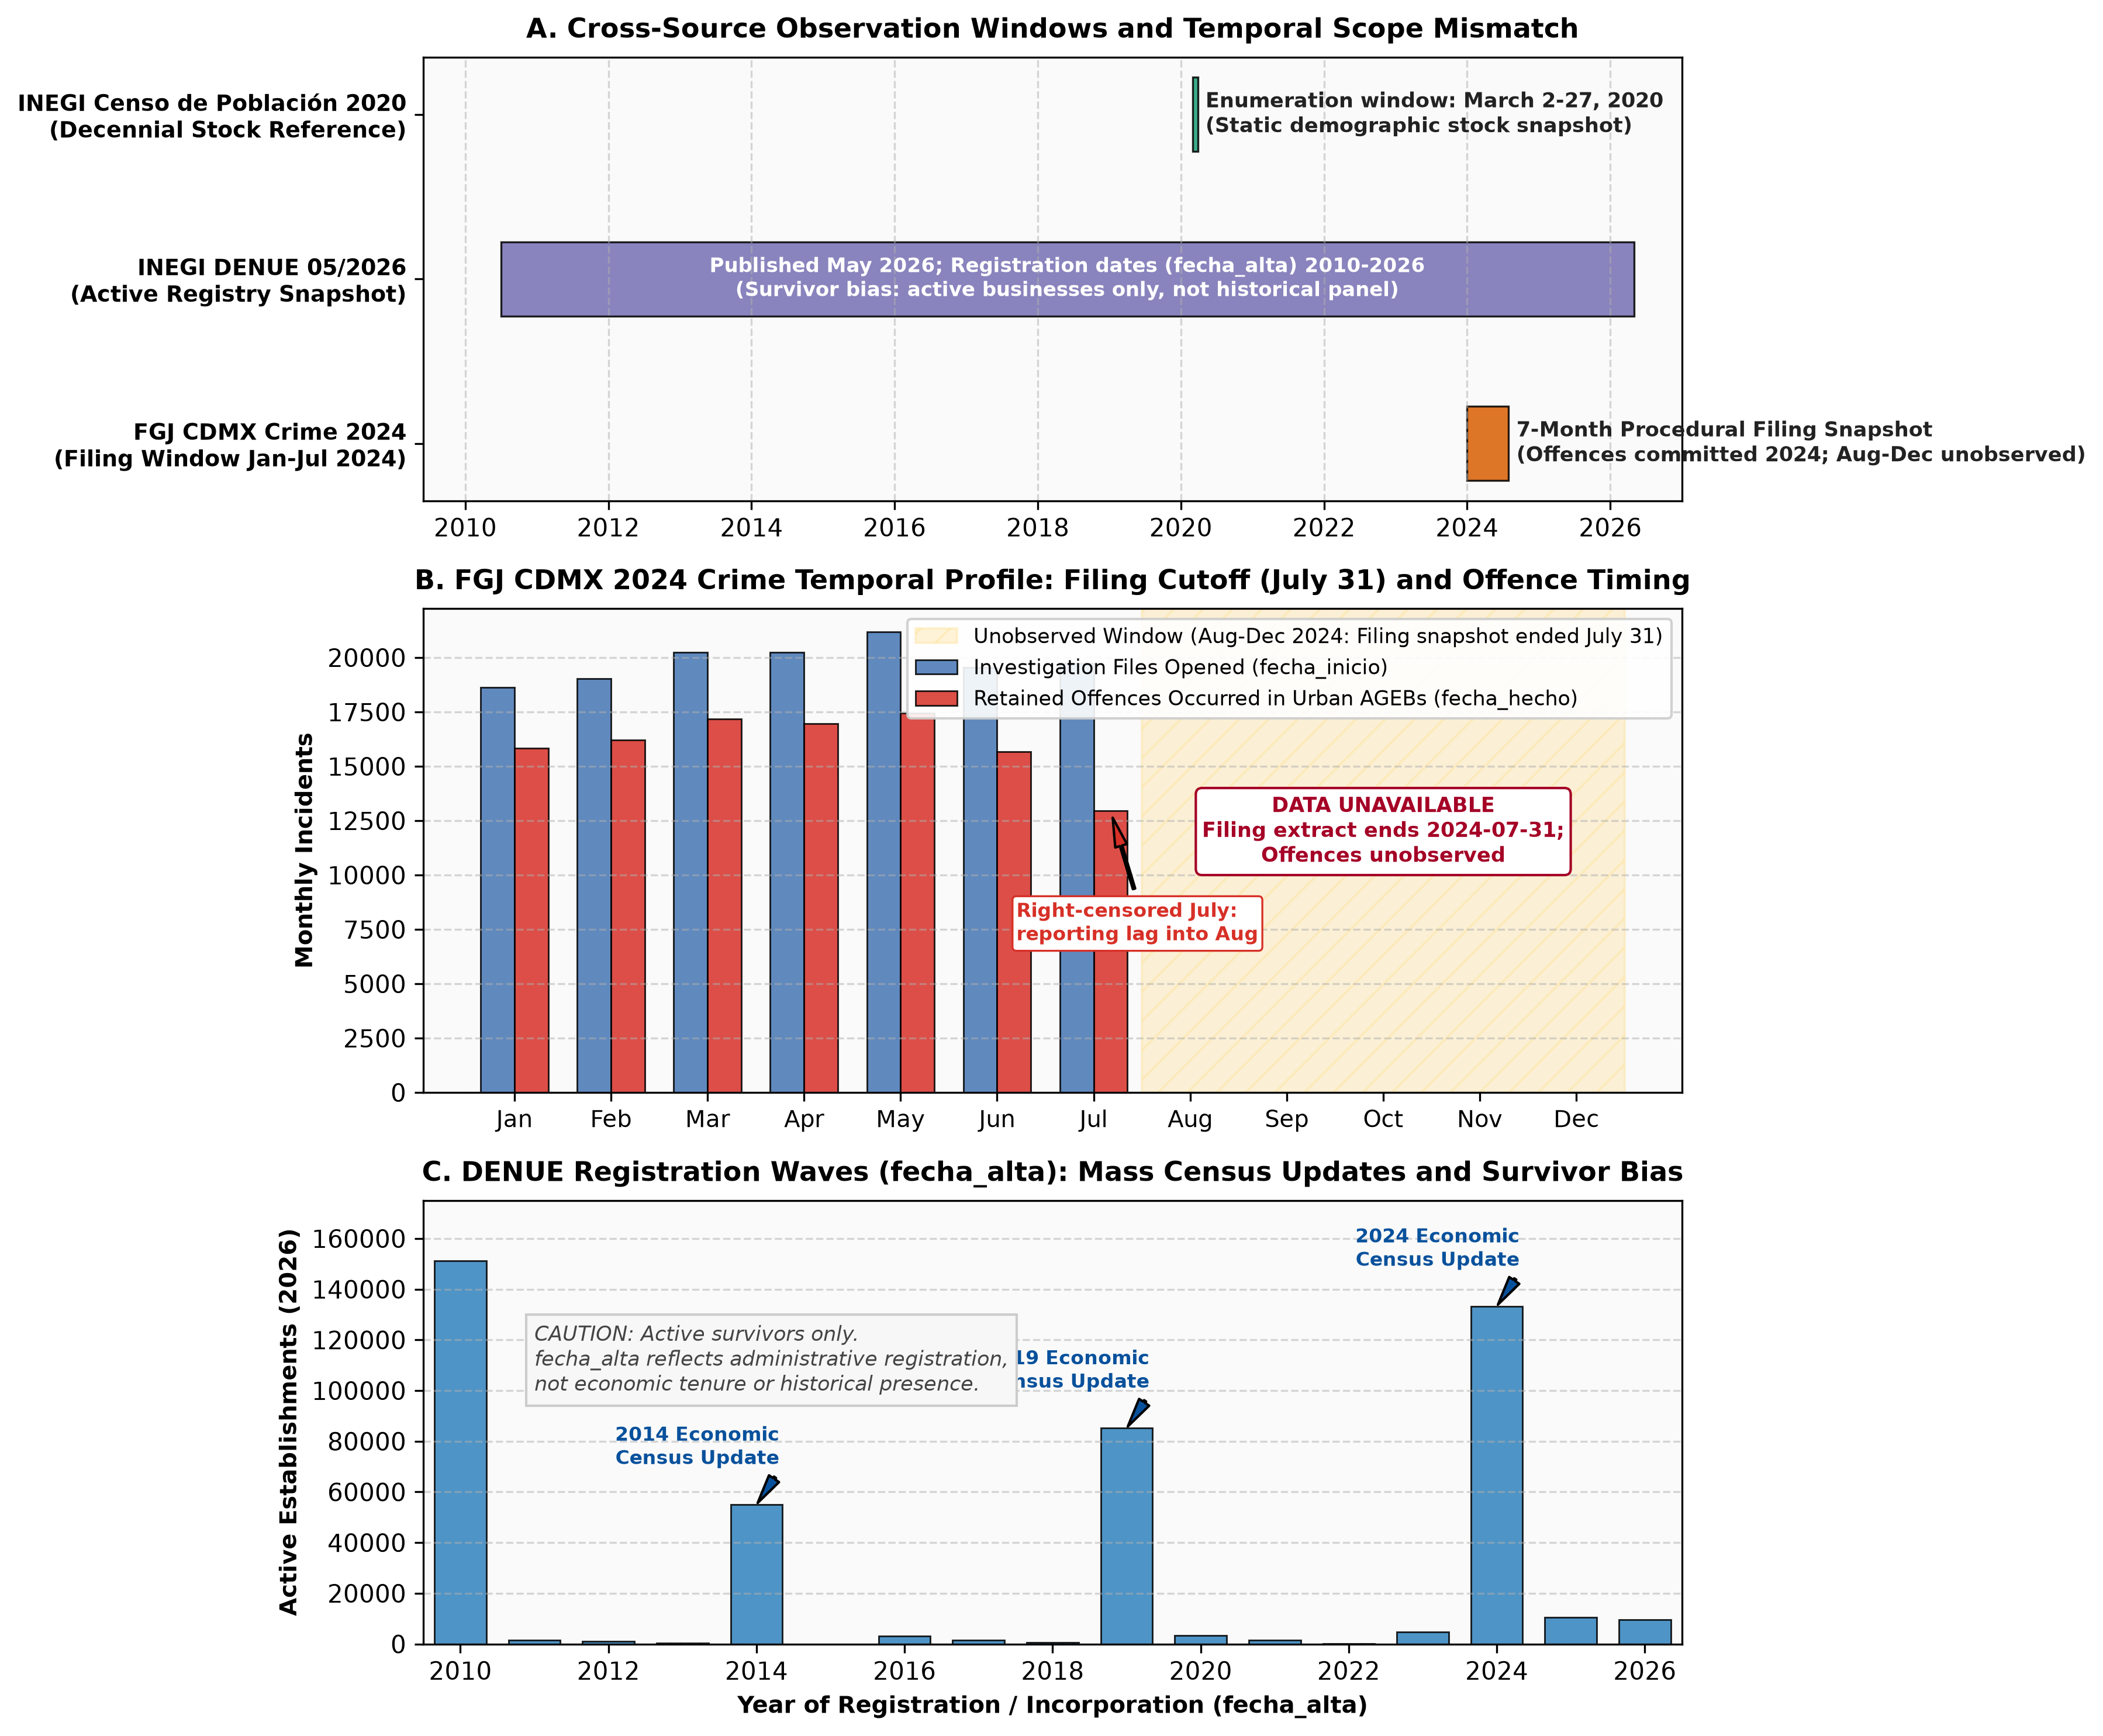

In [4]:
# Profile crime filing and offence dates
crime_info = crime_temporal_and_grain_check()

print("=== FGJ CDMX 2024 Crime Temporal Profile ===")
print(f"Procedural filing window (fecha_inicio):  {crime_info['filing_start']} to {crime_info['filing_end']}")
print(f"Observed filing months:                   {crime_info['filing_months_count']} months (Jan - Jul 2024)")
print(f"Total raw investigation files:            {crime_info['raw_count']:,}")
print(f"Offences occurring in year {CRIME_YEAR}:         {crime_info['year_2024_count']:,}")
print(f"Eligible criminal offences:               {crime_info['eligible_count']:,}")
print(f"Valid geocoded coordinates:               {crime_info['valid_coords_count']:,}")
print(f"Retained incidents in urban AGEBs:        {crime_info['retained_count']:,}")
print(f"Incidents outside urban AGEBs:            {crime_info['outside_count']:,}")

# Generate and export the 3-panel temporal coverage figure
fig, axes = plot_cross_source_temporal_coverage()
plt.close(fig)  # Close memory handle after saving

temporal_fig_path = OUTPUT_FIGURES / "14_temporal_coverage.png"
print(f"\nSaved temporal coverage figure to: {temporal_fig_path}")
display(Image(filename=str(temporal_fig_path)))

### Interpretation of Temporal Figure Findings

1. **Panel A (Observation Windows):** Demonstrates the asynchronous relationship between the static 2020 demographic baseline, the cumulative 2010–2026 economic registry, and the 7-month 2024 public safety flow. Cross-sectional KPI rates (e.g., crime rate per 1,000 residents or business density) must be interpreted as associations across contemporaneously available snapshots, not simultaneous real-time interactions.
2. **Panel B (Filing Cutoff & Right-Censoring):** The procedural filing date (`fecha_inicio`) cuts off sharply on **2024-07-31**. Incident counts by offence date (`fecha_hecho`) remain steady from January through June (~15.8k–17.4k per month) but drop to 12,963 in July. This dip is an artefact of **right-censoring** (offences committed in late July whose investigation files were opened in August or later are excluded from the snapshot). The zero values for August–December represent unobserved periods, not absence of crime.
3. **Panel C (DENUE Registration Waves):** Distinct registration spikes in 2014 (54,995), 2019 (85,152), and 2024 (133,241) align with national Economic Census update cycles. Because inactive businesses are dropped from DENUE, this distribution reflects administrative registration waves and survivorship, not continuous business longevity.

## 4. Source-to-Urban-AGEB Summary Table

The table below reconciles each source dataset from its raw incoming records through filtering and spatial assignment into the final Mexico City urban AGEB data warehouse dimensions and fact tables.

In [5]:
# Generate source integration summary table
summary_table = build_source_integration_summary_table(
    census_results=census_comp,
    denue_results=denue_comp,
    crime_results=crime_info,
)

# Export to figures directory
csv_path = OUTPUT_FIGURES / "14_source_integration_summary.csv"
summary_table.to_csv(csv_path, index=False)
print(f"Exported summary table to: {csv_path}")

display(summary_table)

# Assert core integration invariants
assert summary_table.loc[0, "Retained in Urban AGEBs"] == 2_431
assert summary_table.loc[1, "Retained in Urban AGEBs"] == 2_431
assert summary_table.loc[2, "Retained in Urban AGEBs"] == 461_231
assert summary_table.loc[3, "Retained in Urban AGEBs"] == 112_285
print("\n[OK] All summary table entities reconcile with TEAM_PLAN §3.5 ground truth.")

Exported summary table to: /Users/joseangel/Developer/E2 Datawarehouse Design/merida-urban-intelligence/outputs/figures/14_source_integration_summary.csv


,Source Layer,Publisher,Original Grain,Raw Records,Filtered / Eligible,Retained in Urban AGEBs,Retention % (Raw),Retention % (Eligible),Retained Measure,Integration Status
0,Marco Geoestadístico 2020 (09a.shp),INEGI,One polygon per geostatistical unit,2431,2431,2431,100.00,100.00,"2,431 polygons (792.15 km²)","Complete reference boundary frame (2,348 city ..."
1,Censo de Población y Vivienda 2020,INEGI,"Tabular records (blocks, AGEBs, localities, mu...",2433,2433,2431,99.92,99.92,"9,138,524 residents","Excludes 2 orphan AGEBs (7,108 residents) lack..."
2,DENUE 05/2026,INEGI,One economic establishment point (lat/lon),462732,462729,461231,99.68,99.68,"461,231 establishments",99.84% reported-AGEB agreement; drops 3 invali...
3,Carpetas de Investigación 2024,FGJ CDMX,"One investigation file (carpeta) with date, ca...",138630,119666,112285,81.00,93.83,"112,285 investigation files",7-month filing extract (Jan-Jul); retains 93.8...



[OK] All summary table entities reconcile with TEAM_PLAN §3.5 ground truth.


## 5. Analytical Synthesis and Limitations

### Key Integration Insights
- **Unified Spatial Unit:** The 2,431 urban AGEB polygons of Mexico City (792.15 km² total area; 2,348 city core and 83 outlying urban pueblos) form an empirically sound, topologically clean reference framework.
- **High Data Retention:** Attrition across datasets is minimal and fully documented:
  - Demographic coverage: 99.92% of urban census population retained; 2 non-polygon AGEBs (7,108 residents) safely excluded.
  - Economic coverage: 99.68% of raw DENUE establishments retained (461,231 establishments) with 99.84% boundary concordance.
  - Crime coverage: 93.83% of eligible 2024 crimes (112,285 incidents) successfully geolocated and mapped inside urban AGEBs.

### Interpretation Cautions (Non-Causal Posture)
- **Temporal Asynchrony:** Demographics reflect 2020, economic establishments reflect a 2026 active registry, and public safety files reflect a 7-month snapshot of 2024. Spatial correlations between these layers indicate cross-sectional spatial co-location, not direct causation or dynamic reaction.
- **Reporting Bias in Public Safety:** Investigation files (`carpetas de investigación`) capture reported and formally opened offences, which are subject to substantial dark figure (*cifra negra*) variations across socioeconomic strata and alcaldías.
- **Denominator Sensitivities:** Per-capita crime rates in commercial or transit hub AGEBs with tiny resident populations ($<100$ residents) can become extreme outliers. Downstream spatial analyses (Moran's I, LISA, and regression models) must apply `exclude_low_population=True` to maintain robustness.